In [6]:
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# NOTA SOBRE EL ORIGEN DE DATOS:
# El enlace original (ftp://aftp.cmdl.noaa.gov/.../co2_brw_surface-insitu_1_ccgg_MonthlyData.txt)
# actualmente devuelve un Error 550 / 404 (Not Found)
# Para mantener la integridad del ejercicio y generar la curva histórica completa,
# el código ha sido adaptado para consumir el dataset oficial mensual de la 
# estación de Mauna Loa (Hawái) directamente desde los servidores web de la NOAA.

# 1. Descargamos el archivo (Mauna Loa en lugar de Barrow)
greenhouse_gas_url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"
urllib.request.urlretrieve(url=greenhouse_gas_url, filename="co2-emissions-maunaloa.csv")

#Contar cuántas líneas de metadatos (textos con #) hay realmente
lineas_a_saltar = 0
with open("co2-emissions-maunaloa.csv", "r") as archivo:
    for linea in archivo:
        if linea.startswith("#"):
            lineas_a_saltar += 1
        else:
            break

print(f"Líneas de texto ignoradas: {lineas_a_saltar}")


Líneas de texto ignoradas: 42


In [2]:
# 3. Leemos el archivo usando el número exacto, y le damos el nombre a las columnas
# (Adaptadas a la estructura del dataset de Mauna Loa)
columnas_noaa = ["year", "month", "time_decimal", "value", "deseasonalized", "ndays", "sdev", "unc"]

co2_df = pd.read_csv(
    "co2-emissions-maunaloa.csv", 
    skiprows=lineas_a_saltar, 
    sep="\s+",               # \s+ agrupa cualquier cantidad de espacios
    names=columnas_noaa      # Nombramos las columnas manualmente
)

In [3]:
# 4. LIMPIEZA DE DATOS 
# Primero: Forzamos las columnas a ser formato numérico.
co2_df["value"] = pd.to_numeric(co2_df["value"], errors="coerce")
co2_df["time_decimal"] = pd.to_numeric(co2_df["time_decimal"], errors="coerce")

# Segundo: Cambiamos los valores anómalos de relleno por np.nan
co2_df.loc[co2_df["value"] < 0, "value"] = np.nan

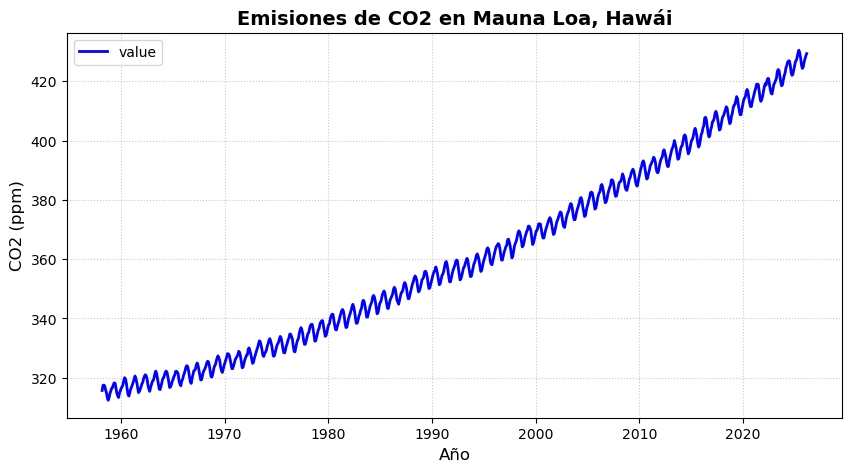

In [5]:
# 5. GRAFICAMOS EL RESULTADO FINAL
co2_df.plot(x="time_decimal", y="value", figsize=(10, 5), color="blue", linewidth=2)

plt.title("Emisiones de CO2 en Mauna Loa, Hawái", fontsize=14, fontweight="bold")
plt.xlabel("Año", fontsize=12)
plt.ylabel("CO2 (ppm)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.7)

plt.show()

Interpretación del Gráfico

El gráfico evidencia la evolución de las concentraciones de CO2 en la atmósfera desde 1958, destacando dos comportamientos clave:

Tendencia histórica al alza: Muestra un crecimiento sostenido e ininterrumpido a lo largo de las décadas, pasando de aproximadamente 315 ppm a más de 420 ppm en la actualidad.

Ciclo anual: Las pequeñas oscilaciones que se repiten cada año reflejan el ciclo natural de las estaciones. El CO2 baja en primavera/verano cuando la vegetación del planeta lo absorbe, y vuelve a subir en otoño/invierno cuando las plantas lo liberan.

En resumen: la gráfica muestra un claro calentamiento global a largo plazo (la línea ascendente), sobre el cual se superpone la "respiración" anual de la Tierra (el zigzag).